In [19]:
# train
!python3 main.py --epochs 10 --batch_size 64 --lr 0.001

MNIST Classification with PyTorch

Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU

Loading MNIST dataset...
Found train-images-idx3-ubyte.gz on disk. Loading...
Found train-labels-idx1-ubyte.gz on disk. Loading...
Found t10k-images-idx3-ubyte.gz on disk. Loading...
Found t10k-labels-idx1-ubyte.gz on disk. Loading...
Training data: (60000, 28, 28), Training labels: (60000,)
Test data: (10000, 28, 28), Test labels: (10000,)

Model Parameters:
  Total: 1,702,090
  Trainable: 1,702,090

Starting Training...


Epoch 1/10
----------------------------------------
  Train Loss: 0.1756 | Train Acc: 94.96%                                        
  Test Loss:  0.0390 | Test Acc:  98.77%

Epoch 2/10
----------------------------------------
  Train Loss: 0.0731 | Train Acc: 97.76%                                        
  Test Loss:  0.0262 | Test Acc:  99.05%

Epoch 3/10
----------------------------------------
  Train Loss: 0.0578 | Train Acc: 98.22%                              

In [20]:
# evaluate
!python3 main.py --no_train --load_model "model/mnist_model.pth"

MNIST Classification with PyTorch

Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU

Loading MNIST dataset...
Found train-images-idx3-ubyte.gz on disk. Loading...
Found train-labels-idx1-ubyte.gz on disk. Loading...
Found t10k-images-idx3-ubyte.gz on disk. Loading...
Found t10k-labels-idx1-ubyte.gz on disk. Loading...
Training data: (60000, 28, 28), Training labels: (60000,)
Test data: (10000, 28, 28), Test labels: (10000,)

Model Parameters:
  Total: 1,702,090
  Trainable: 1,702,090

Loading pretrained model from model/mnist_model.pth...
Model loaded successfully!

Final Evaluation
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      1.00      1032
           3       0.99      1.00      1.00      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99    

Training History:


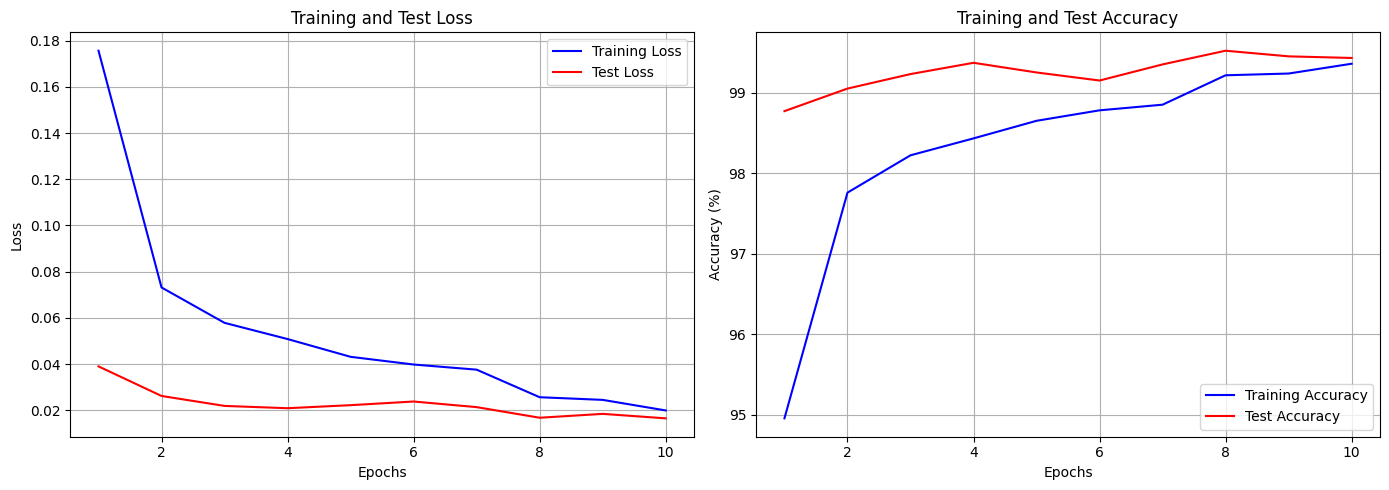


Confusion Matrix:


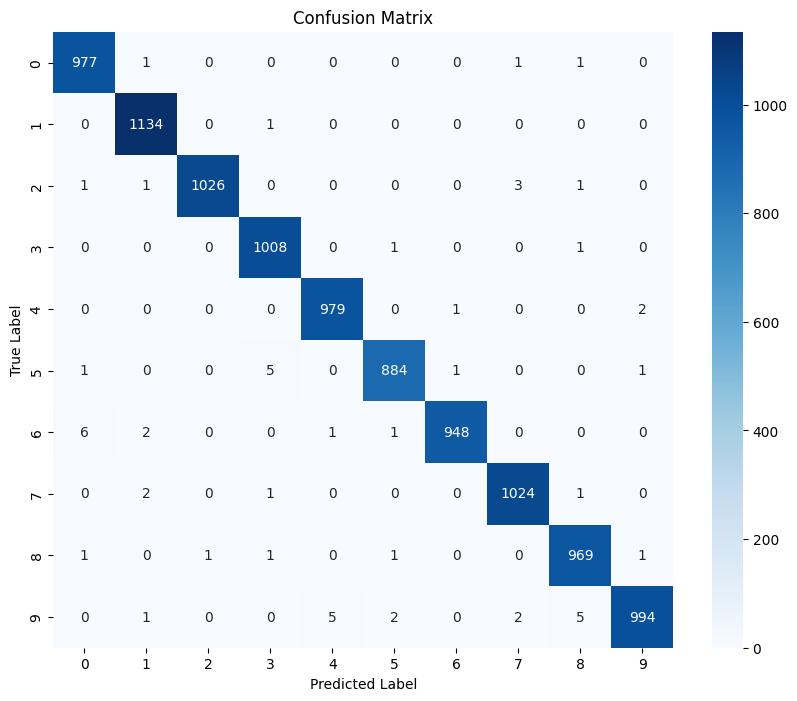


Sample Predictions:


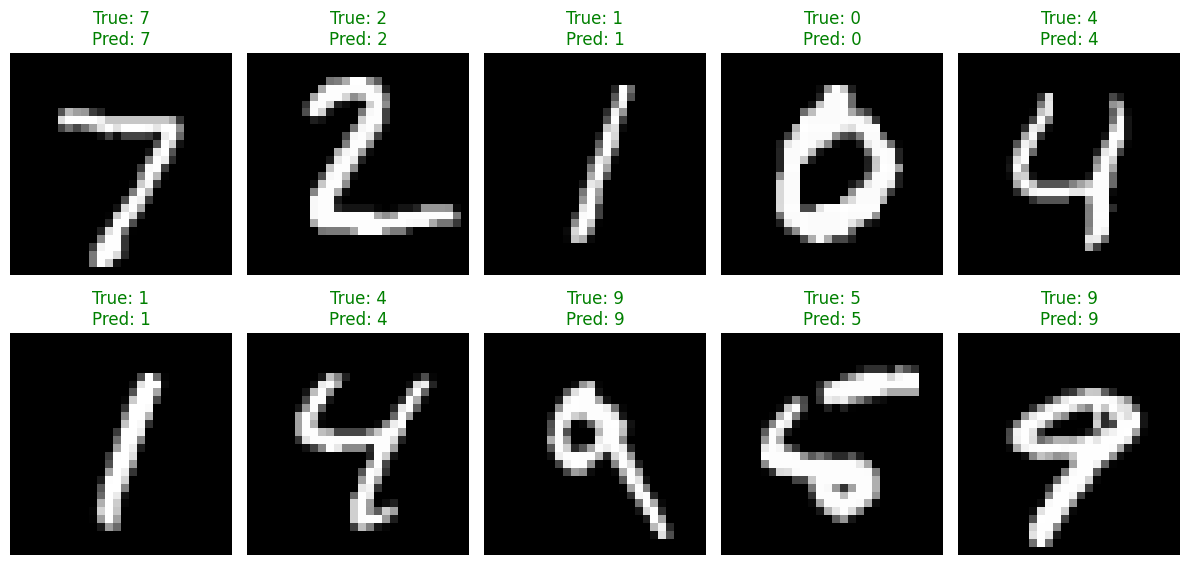

ROC Curves:


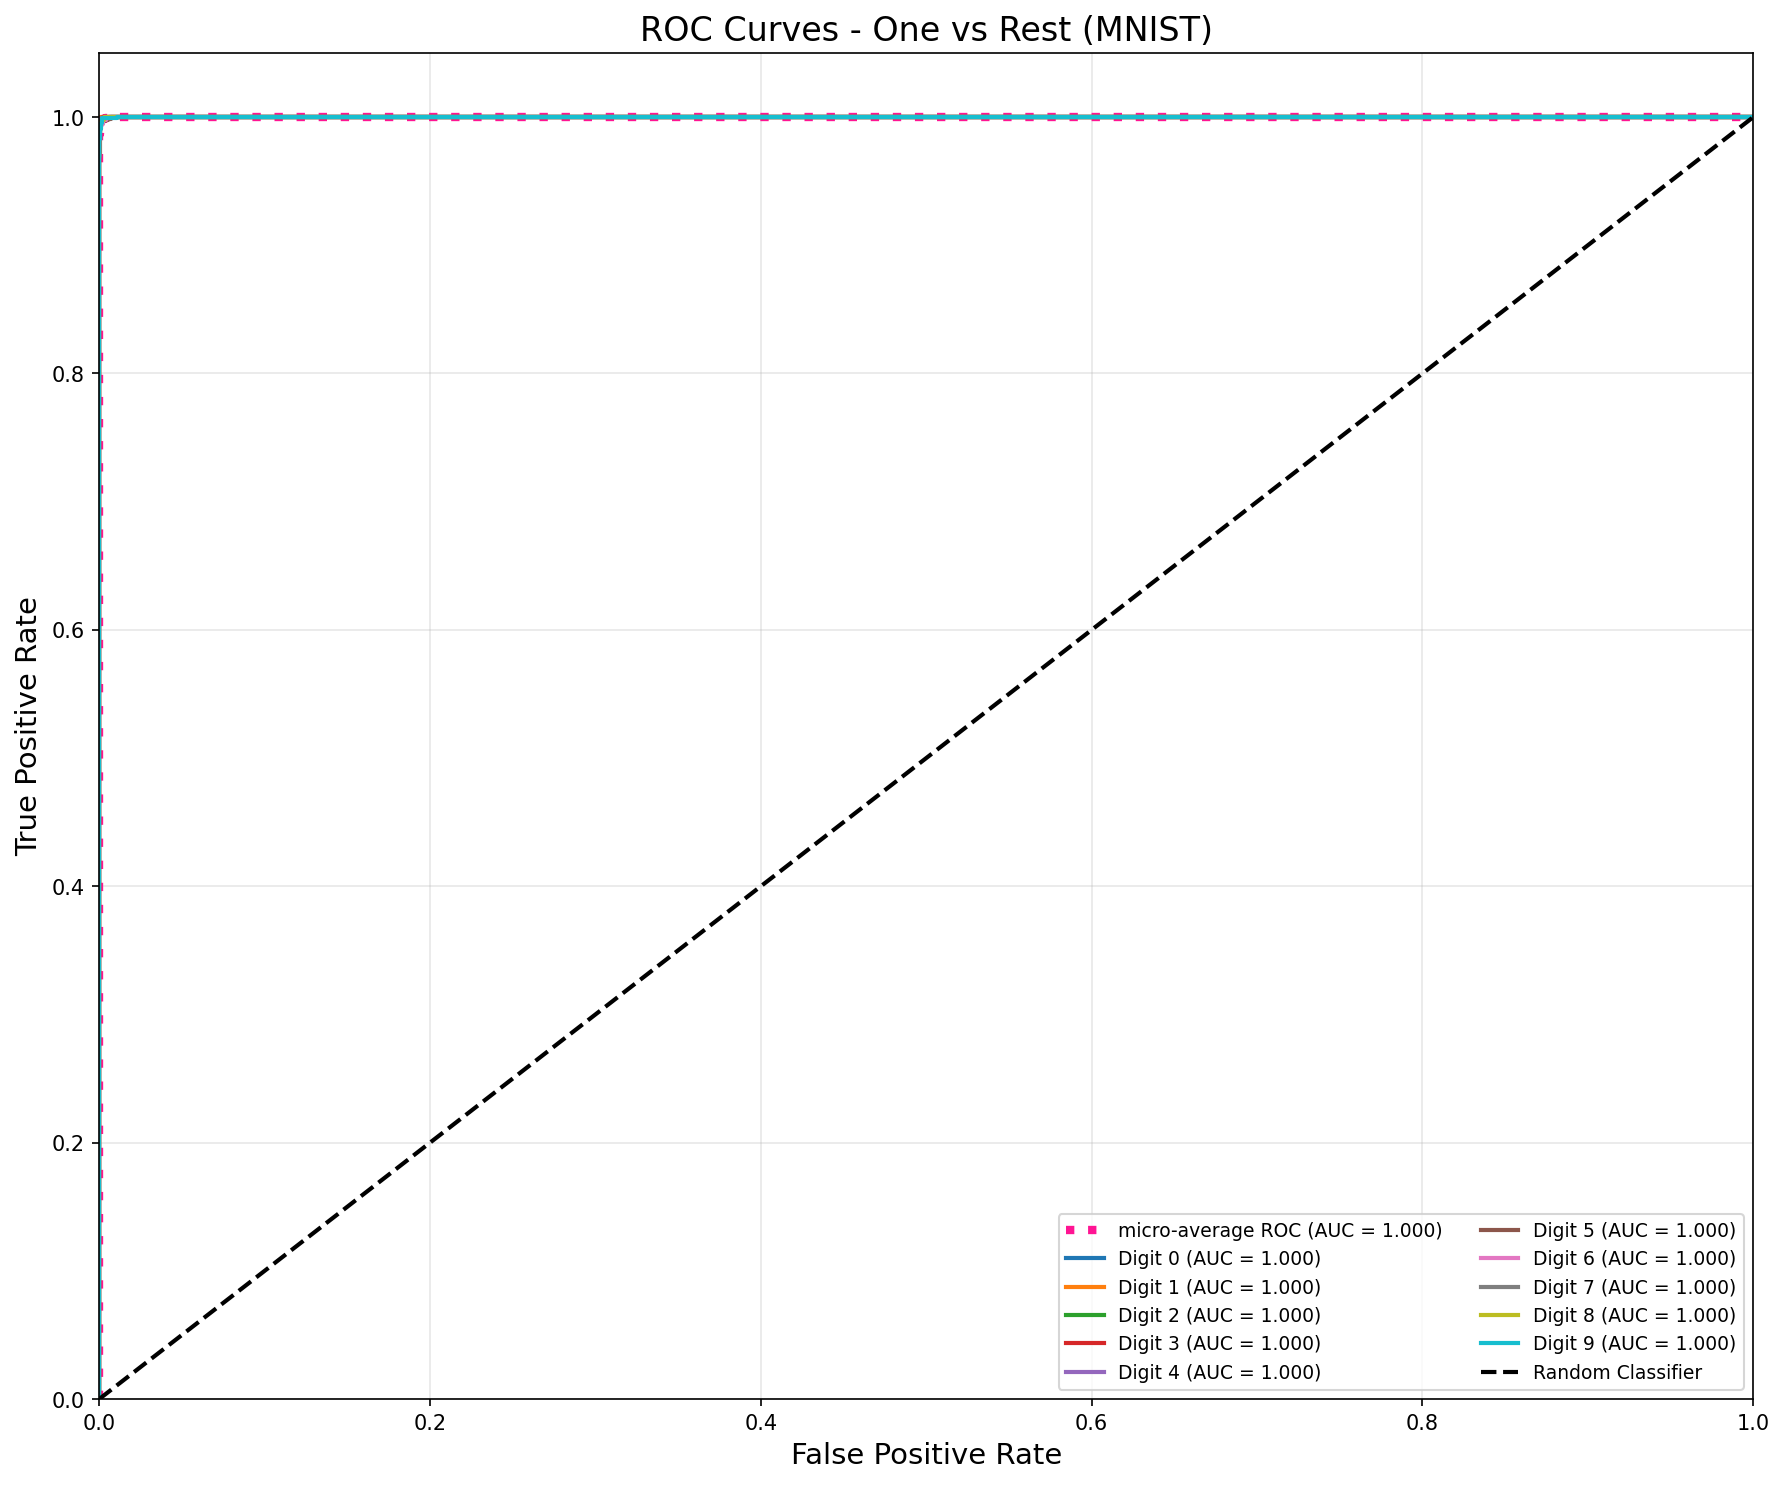


Precision-Recall Curves:


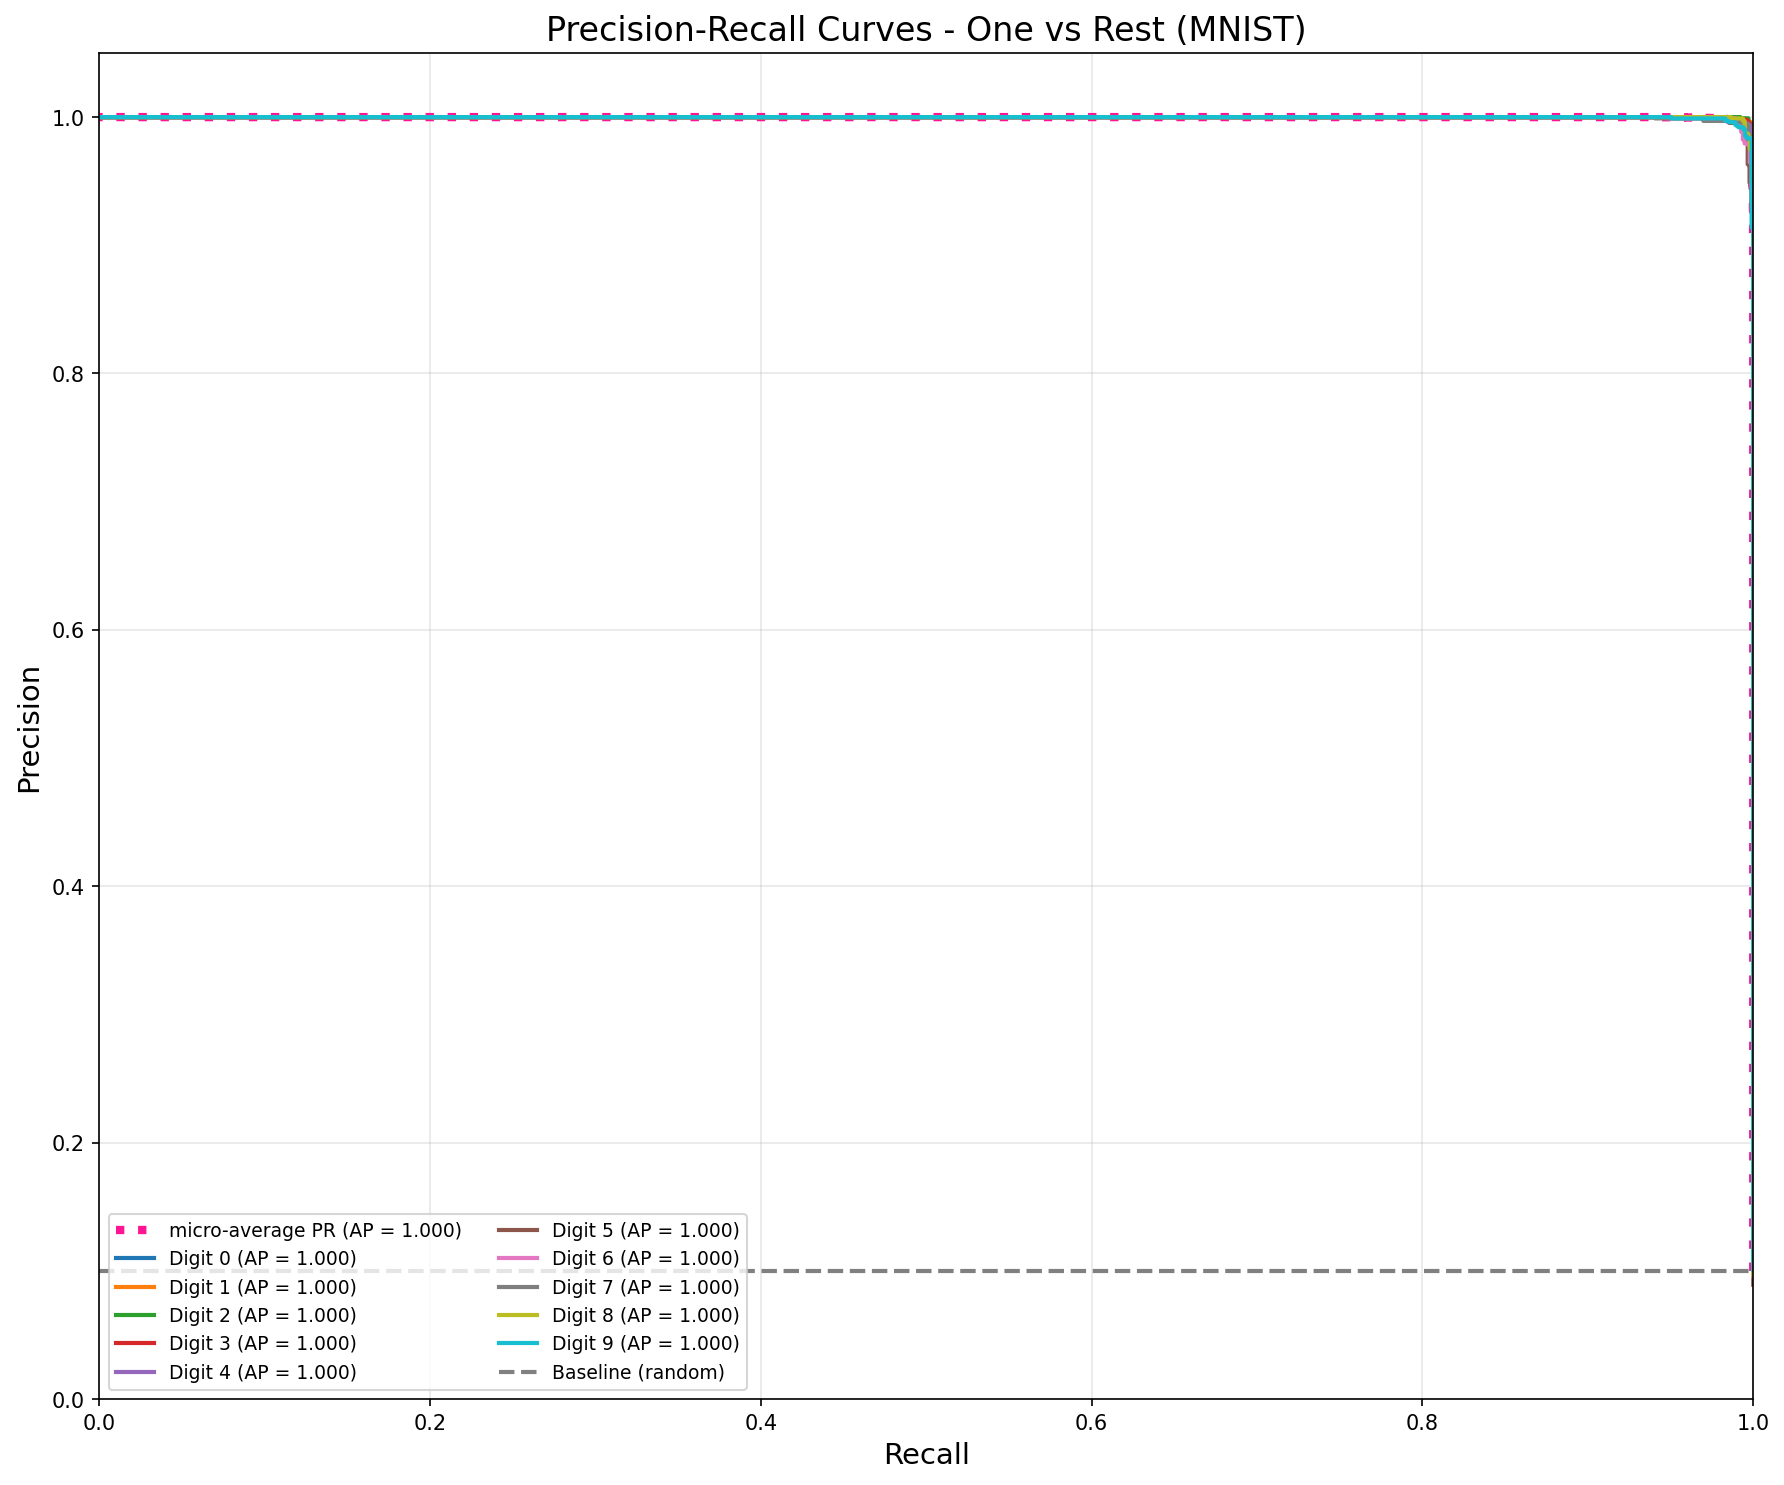

In [11]:
# show diagrams
from IPython.display import Image

print("Training History:")
display(Image('images/training_history.png'))

print("\nConfusion Matrix:")
display(Image('images/confusion_matrix.png'))

print("\nSample Predictions:")
display(Image('images/predictions.png'))

print("ROC Curves:")
display(Image('images/roc_curves.png'))

print("\nPrecision-Recall Curves:")
display(Image('images/precision_recall_curves.png'))


Using device: cuda
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU
Found train-images-idx3-ubyte.gz on disk. Loading...
Found train-labels-idx1-ubyte.gz on disk. Loading...
Found t10k-images-idx3-ubyte.gz on disk. Loading...
Found t10k-labels-idx1-ubyte.gz on disk. Loading...


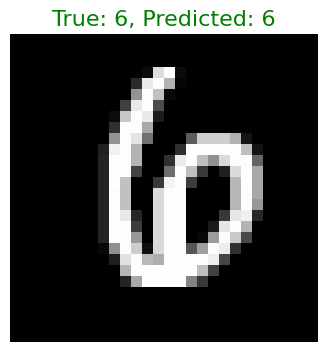

In [8]:
#  predict for an image
import torch
from utils import get_device, load_mnist_from_github
from model import create_model
import matplotlib.pyplot as plt

# load model
device = get_device()
model = create_model(device)
checkpoint = torch.load('model/mnist_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# load dataset
(X_train, y_train), (X_test, y_test) = load_mnist_from_github()

# choose a random image
import numpy as np
idx = np.random.randint(0, len(X_test))
image = X_test[idx]
true_label = y_test[idx]

# predict a label
image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device) / 255.0
with torch.no_grad():
    output = model(image_tensor)
    pred_label = output.argmax(1).item()

# show image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
color = 'green' if true_label == pred_label else 'red'
plt.title(f'True: {true_label}, Predicted: {pred_label}', color=color, fontsize=16)
plt.axis('off')
plt.show()